In [130]:
import numpy as np
import matplotlib.pyplot as plt
from pyfwat.utils.pario import chpar

In [131]:
xmin, xmax = -150000, 150000
ymin, ymax = -150000, 150000
zmin, zmax = -50000, 0

# start point in x, y, z for src
x0, y0, z0 = -148000, -148000, -40000
# end point in x, y, z for src
x1, y1, z1 = 148000, 148000, -5000

# start point in x, y, z for rec
rx0, ry0 = -120000, -120000
# end point in x, y, z for rec
rx1, ry1 = 120000, 120000

In [132]:
# randomly create src positions
n_src = 20
src_x = np.random.uniform(x0, x1, n_src)
src_y = np.random.uniform(y0, y1, n_src)
src_z = np.random.uniform(z0, z1, n_src)

# create receiver positions on a grid
n_rec_x = 10
n_rec_y = 10
rec_x = np.linspace(rx0, rx1, n_rec_x)
rec_y = np.linspace(ry0, ry1, n_rec_y)
rec_X, rec_Y = np.meshgrid(rec_x, rec_y)
rec_x_flat = rec_X.flatten()
rec_y_flat = rec_Y.flatten()
n_rec = rec_x_flat.shape[0]

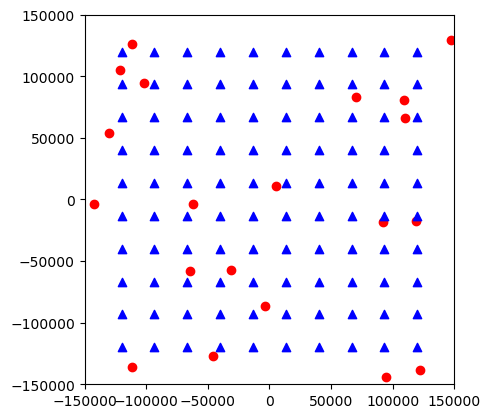

In [133]:
# plot src positions
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(src_x, src_y, c='r', marker='o')
ax.scatter(rec_x_flat, rec_y_flat, c='b', marker='^')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

In [134]:
# change src position in CMTCOLUTION
for i in range(n_src):
    with open(f'src_rec/CMTSOLUTION_EV{i+1:02d}', 'r') as f:
        solution = f.read()
    solution = chpar(solution, 'latitude', src_y[i], type='solution')
    solution = chpar(solution, 'longitude', src_x[i], type='solution')
    solution = chpar(solution, 'depth', -src_z[i]/1000, type='solution')
    with open(f'src_rec/CMTSOLUTION_EV{i+1:02d}', 'w') as f:
        f.write(solution)


In [136]:
for i in range(n_src):
    with open(f'src_rec/STATIONS_EV{i+1:02d}', 'w') as f:
        for j in range(n_rec):
            f.write(f'ST{j+1:03d} MX {rec_y_flat[j]} {rec_x_flat[j]} 0.0 0.0\n')

In [135]:
# create a src list
with open('src_rec/sources_leq.dat', 'w') as f:
    for i in range(n_src):
        f.write(f'EV{i+1:02d} {src_y[i]} {src_x[i]} { -src_z[i]/1000} 0.0 1.0\n')